# Úkol č. 1 - redukce dimenzionality a binární klasifikace

* Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML2/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML2/homeworks/index.html).
* Pokud odevzdáte úkol po prvním termínu ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
* V rámci tohoto úkolu se musíte vypořádat s vysokou dimenzí problému a poté úspěšně aplikovat vhodný klasfikační model.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena!**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budou strhávány body.

## Zdroj dat

 * Zdrojem dat jsou soubory `train.csv` a `evaluate.csv`.
 * Jedná se o obrázky 28x28 pixelů ve stupních šedi, které byly získány z [Fashion Mnist datasetu](https://www.kaggle.com/datasets/zalando-research/fashionmnist).
 * Soubor `train.csv` obsahuje trénovací data.
 * Cílová (vysvětlovaná) proměnná se jmenuje **label**.
 * Soubor `evaluate.csv` obsahuje testovací data bez hodnot skutečných labelů.

## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé) vypracování získáte **25 bodů**:
  * V notebooku načtěte data ze souboru `train.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování, porovnávání modelů a následnou predikci výkonnosti finálního modelu.
  * Proveďte základní průzkum dat a svá pozorování diskutujte. Některé obrázky také zobrazte.
  * Postupně aplikujte modely **SVM**, **naivní Bayesův klasifikátor** a **LDA**, přičemž pro každý z nich:
      * Okomentujte vhodnost daného modelu pro daný typ úlohy.
      * Vyberte si hlavní hyperparametry k ladění (pokud model má hyperparametry) a najděte jejich nejlepší hodnoty.
      * U SVM vyzkoušejte alespoň dvě různé jádrové funkce.
      * Získané výsledky vždy řádně okomentujte.
<br/><br/>

  * Použijte natrénovaný generativní model Naivního Bayesova klasifikátoru nebo Lineární diskriminační analýzy (podle Vaší volby) a vygenerujte pro každou třídu 5 datových bodů, které následně přetransformujte do rozměrů 28x28 a zobrazte pomocí `imshow`. Diskutujte kvalitu vygenerovaných dat. K vygenerování můžete využít funkci [multivariate_normal](https://numpy.org/doc/2.2/reference/random/generated/numpy.random.multivariate_normal.html) z `numpy`.

  * Postupně aplikujte metody redukce dimenzionality PCA a LLE, přičemž pro každou z nich: 
      * Zopakujte předchozí kroky aplikace modelů (žádné další generování už nedělejte) a pokuste se je vylepšit.
      * Zkoumejte jaká dimenze je z hlediska výkonnosti finálního modelu nejlepší.
      * Získané výsledky vždy řádně okomentujte.
<br/><br/>
    
  * Ze všech zkoušených možností vyberte finální model a odhadněte, jakou přesnost můžete očekávat na nových datech, která jste doposud neměli k dispozici. _Pozor na metodické chyby!_
  
  * Nakonec načtěte vyhodnocovací data ze souboru`evaluate.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **label** a identifikátory do sloupce **ID**. Tento soubor též odevzdejte (uložte do projektu vedle notebooku).
   
       * Ukázka, jak by mělo vypadat prvních několik řádků souboru `results.csv` (obecně s jinými hodnotami):
  
```
ID,label
0,0
1,1
...
```

## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML2/homeworks/index.html.
  * Vytvořte i csv soubor `results.csv` s predikcemi a uložte ho v rámci projektu vedle ipython notebooku.

In [170]:
### odtud už je to Vaše
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("train.csv")

X = df.drop(columns = "label").values / 255.0
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")


Train size: 900
Validation size: 300
Test size: 300


We divide by 255 to normailize because range of pixel is 0 to 255

Missing values per column:
0


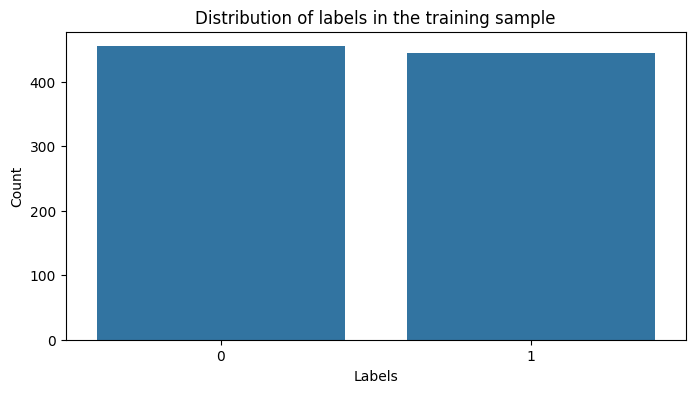

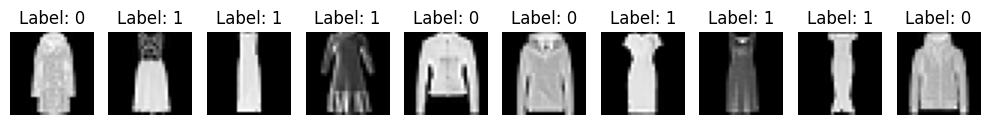

In [171]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("Missing values per column:")
print(pd.DataFrame(X_train).isnull().sum().sum())

plt.figure(figsize=(8, 4))
sns.countplot(x=y_train)
plt.title("Distribution of labels in the training sample")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()

def plot_images(images, labels, n=10):
    plt.figure(figsize=(n, 20))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap="gray")
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_images(X_train, y_train, n=10)

In [172]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [173]:
param_grid_rbf = {
    "C": [1, 10],
    "gamma": [0.01, 0.001],
    "kernel": ["rbf"]
}

grid_rbf = GridSearchCV(SVC(), param_grid_rbf, cv=3, scoring="accuracy", n_jobs=-1)
grid_rbf.fit(X_train, y_train)

print("Best params (RBF):", grid_rbf.best_params_)

y_pred_rbf = grid_rbf.predict(X_val)
print("Accuracy (RBF):", accuracy_score(y_val, y_pred_rbf))
print(classification_report(y_val, y_pred_rbf))

Best params (RBF): {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Accuracy (RBF): 0.95
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       152
           1       0.95      0.95      0.95       148

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



In [187]:
param_grid_linear = {
    "C": [0.1, 1, 10],
    "kernel": ["linear"]
}

grid_linear = GridSearchCV(SVC(), param_grid_linear, cv=3, scoring="accuracy", n_jobs=-1)
grid_linear.fit(X_train, y_train)

print("Best params (Linear):", grid_linear.best_params_)

y_pred_linear = grid_linear.predict(X_val)
print("Accuracy (Linear):", accuracy_score(y_val, y_pred_linear))

Best params (Linear): {'C': 0.1, 'kernel': 'linear'}
Accuracy (Linear): 0.94


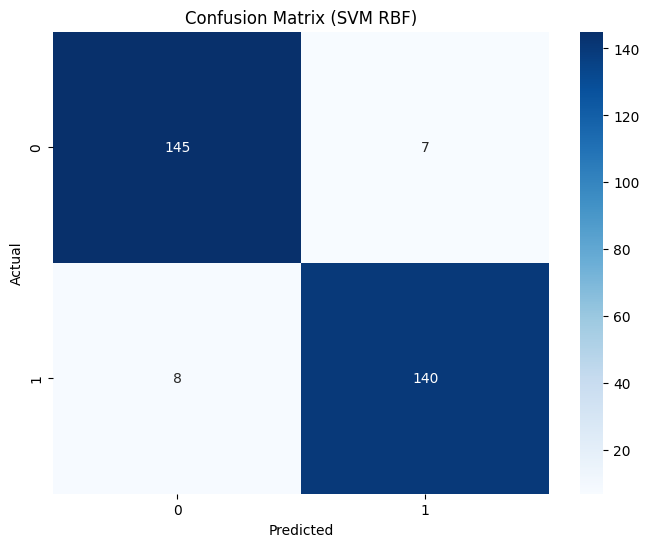

In [175]:
def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_val, y_pred_rbf, title="Confusion Matrix (SVM RBF)")

Accuracy (Naive Bayes): 0.8566666666666667
              precision    recall  f1-score   support

           0       0.92      0.78      0.85       152
           1       0.81      0.93      0.87       148

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.87      0.86      0.86       300



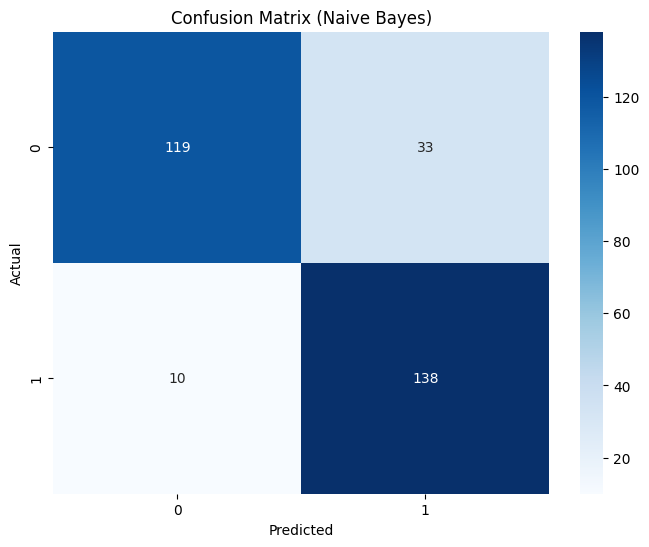

In [176]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_val)

print("Accuracy (Naive Bayes):", accuracy_score(y_val, y_pred_nb))
print(classification_report(y_val, y_pred_nb))

plot_confusion(y_val, y_pred_nb, title="Confusion Matrix (Naive Bayes)")

Generated images (NB) for label 0:


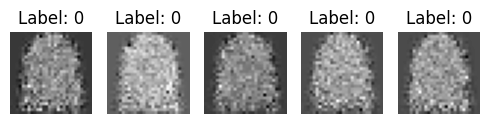

Generated images (NB) for label 1:


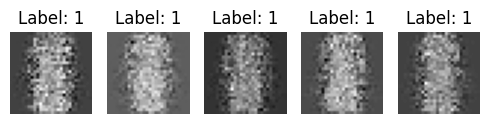

In [177]:
from numpy.random import multivariate_normal
import matplotlib.pyplot as plt

def plot_images(images, labels=None, n=5):
    plt.figure(figsize=(n, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap="gray")
        if labels is not None:
            plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

classes = np.unique(y_train)
generated_images = []

for cls in classes:
    mean = nb_model.theta_[cls]
    var = nb_model.var_[cls]
    cov = np.diag(var)

    samples = multivariate_normal(mean, cov, size=5)
    generated_images.append(samples)

for idx, cls_samples in enumerate(generated_images):
    print(f"Generated images (NB) for label {idx}:")
    plot_images(cls_samples, labels=[idx]*5, n=5)


Generated images (LDA) for label 0:


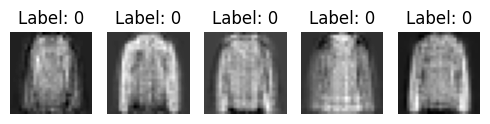

Generated images (LDA) for label 1:


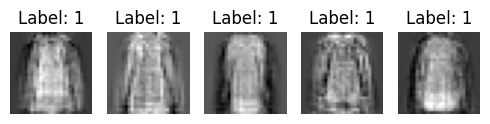

In [178]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from numpy.random import multivariate_normal
import matplotlib.pyplot as plt

lda_model = LinearDiscriminantAnalysis(store_covariance=True)
lda_model.fit(X_train, y_train)

classes = np.unique(y_train)
generated_lda = []

for cls in classes:
    mean = lda_model.means_[cls]
    cov = lda_model.covariance_
    samples = multivariate_normal(mean, cov, size=5)
    generated_lda.append(samples)

def plot_images(images, labels=None, n=5):
    plt.figure(figsize=(n, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap="gray")
        if labels is not None:
            plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

for idx, cls_samples in enumerate(generated_lda):
    print(f"Generated images (LDA) for label {idx}:")
    plot_images(cls_samples, labels=[idx]*5, n=5)


SVM (rbf) | PCA dim=10: Accuracy = 0.9367
SVM (linear) | PCA dim=10: Accuracy = 0.9400
Naive Bayes | PCA dim=10: Accuracy = 0.8867
LDA | PCA dim=10: Accuracy = 0.9300
SVM (rbf) | PCA dim=20: Accuracy = 0.9467
SVM (linear) | PCA dim=20: Accuracy = 0.9400
Naive Bayes | PCA dim=20: Accuracy = 0.8933
LDA | PCA dim=20: Accuracy = 0.9467
SVM (rbf) | PCA dim=50: Accuracy = 0.9533
SVM (linear) | PCA dim=50: Accuracy = 0.9533
Naive Bayes | PCA dim=50: Accuracy = 0.8900
LDA | PCA dim=50: Accuracy = 0.9467
SVM (rbf) | PCA dim=100: Accuracy = 0.9467
SVM (linear) | PCA dim=100: Accuracy = 0.9533
Naive Bayes | PCA dim=100: Accuracy = 0.8900
LDA | PCA dim=100: Accuracy = 0.9367
SVM (rbf) | PCA dim=150: Accuracy = 0.9467
SVM (linear) | PCA dim=150: Accuracy = 0.9500
Naive Bayes | PCA dim=150: Accuracy = 0.8867
LDA | PCA dim=150: Accuracy = 0.9367


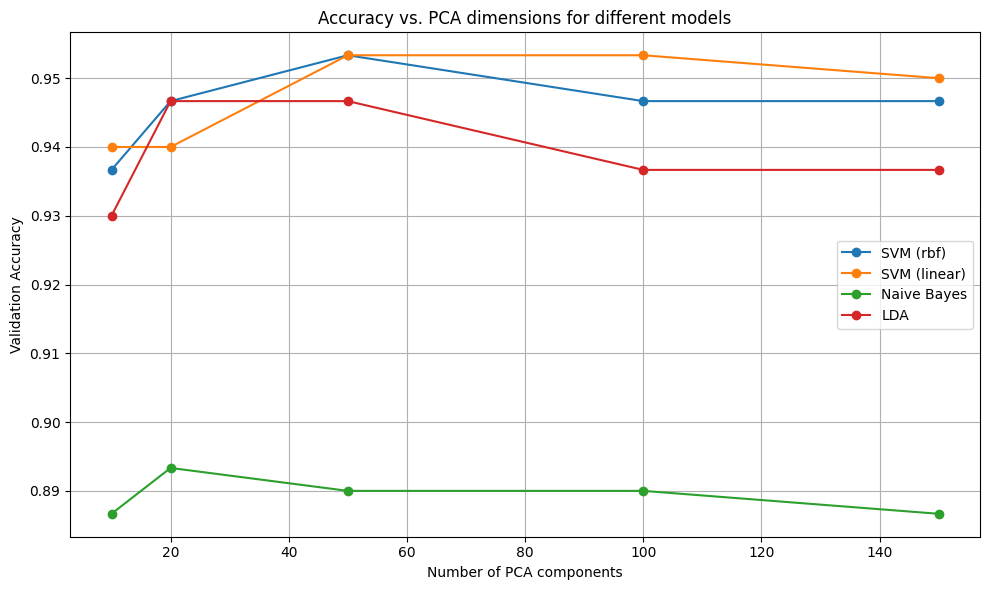

In [179]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

dimensions = [10, 20, 50, 100, 150]

models = {
    "SVM (rbf)": SVC(kernel="rbf", C=1),
    "SVM (linear)": SVC(kernel='linear', C=0.1),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis()
}

results = {name: [] for name in models.keys()}

for dim in dimensions:
    pca = PCA(n_components=dim)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    for name, model in models.items():
        model.fit(X_train_pca, y_train)
        preds = model.predict(X_val_pca)
        acc = accuracy_score(y_val, preds)
        results[name].append(acc)

        print(f"{name} | PCA dim={dim}: Accuracy = {acc:.4f}")

plt.figure(figsize=(10, 6))
for name, accs in results.items():
    plt.plot(dimensions, accs, marker='o', label=name)

plt.title("Accuracy vs. PCA dimensions for different models")
plt.xlabel("Number of PCA components")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Average in range 50 to 100 for SVM (rbf) like our potencial the best model we got the most possible accurancy so we will take 50 like our number of component

SVM (rbf) | LLE dim=10: Accuracy = 0.7467
SVM (linear kernel) | LLE dim=10: Accuracy = 0.8933
Naive Bayes | LLE dim=10: Accuracy = 0.8467
LDA | LLE dim=10: Accuracy = 0.8600
SVM (rbf) | LLE dim=20: Accuracy = 0.7433
SVM (linear kernel) | LLE dim=20: Accuracy = 0.8900
Naive Bayes | LLE dim=20: Accuracy = 0.8233
LDA | LLE dim=20: Accuracy = 0.8800
SVM (rbf) | LLE dim=30: Accuracy = 0.7433
SVM (linear kernel) | LLE dim=30: Accuracy = 0.8933
Naive Bayes | LLE dim=30: Accuracy = 0.8233
LDA | LLE dim=30: Accuracy = 0.8867
SVM (rbf) | LLE dim=50: Accuracy = 0.7733
SVM (linear kernel) | LLE dim=50: Accuracy = 0.8733
Naive Bayes | LLE dim=50: Accuracy = 0.8133
LDA | LLE dim=50: Accuracy = 0.8733
SVM (rbf) | LLE dim=100: Accuracy = 0.8067
SVM (linear kernel) | LLE dim=100: Accuracy = 0.8667
Naive Bayes | LLE dim=100: Accuracy = 0.7633
LDA | LLE dim=100: Accuracy = 0.8533


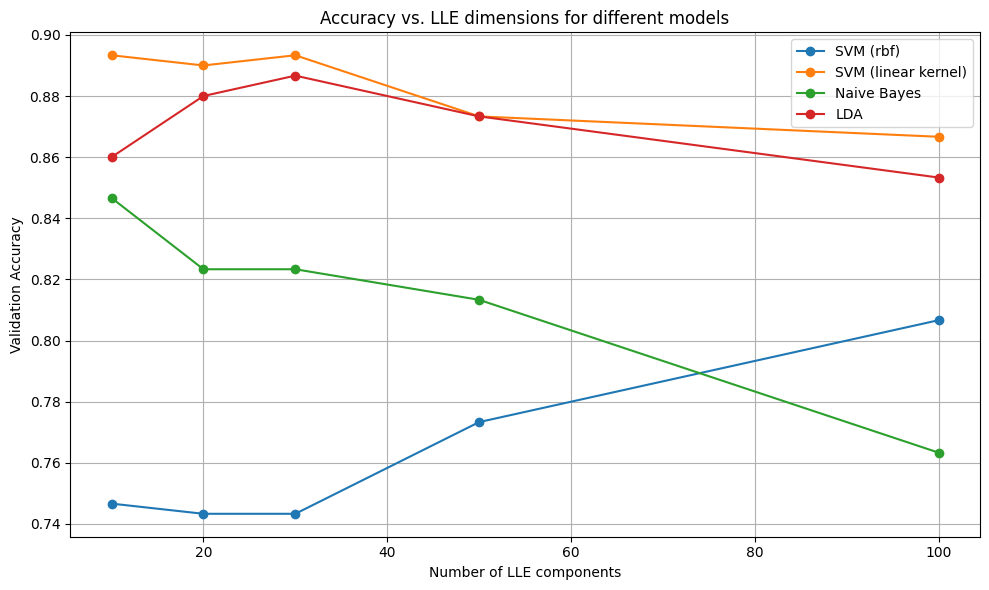

In [184]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, accuracy_score

dimensions = [10, 20, 30, 50, 100]

models = {
    "SVM (rbf)": SVC(kernel="rbf", C=1),
    "SVM (linear kernel)": SVC(kernel="linear", C=1),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis()
}

results = {name: [] for name in models}

for dim in dimensions:
    lle = LocallyLinearEmbedding(n_components=dim, n_neighbors=10)
    X_train_lle = lle.fit_transform(X_train)
    X_val_lle = lle.fit_transform(X_val)

    for name, model in models.items():
        model.fit(X_train_lle, y_train)
        preds = model.predict(X_val_lle)
        acc = accuracy_score(y_val, preds)
        results[name].append(acc)
        print(f"{name} | LLE dim={dim}: Accuracy = {acc:.4f}")

plt.figure(figsize=(10, 6))
for name, accs in results.items():
    plt.plot(dimensions, accs, marker='o', label=name)

plt.title("Accuracy vs. LLE dimensions for different models")
plt.xlabel("Number of LLE components")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

So we can see than it is worse then privious

In [185]:
best_model = Pipeline([
    ("svm", SVC(kernel='rbf', C=10, gamma=0.01))
])

X_final_train = np.vstack([X_train, X_val])
y_final_train = np.concatenate([y_train, y_val])

best_model.fit(X_final_train, y_final_train)

y_pred_test = best_model.predict(X_test)

print("\nFinal:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))


Final:
Accuracy: 0.9567
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       152
           1       0.96      0.95      0.96       148

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



So we can use SVM (rbf) without regresion like our the best model

In [186]:
df_eval = pd.read_csv("evaluate.csv")

ids = df_eval["ID"]

X_eval = df_eval.drop(columns=[df_eval.columns[0]]).values / 255.0

y_eval_pred = best_model.predict(X_eval)

submission = pd.DataFrame({
    "Id": ids,
    "Label": y_eval_pred
})

submission.to_csv("submission.csv", index=False)
print("submission.csv is ready")

submission.csv is ready
